<a href="https://colab.research.google.com/github/rajdatadev/Sales-analysis-using-python/blob/main/sales_data_analysis_by_Pranav.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project: Retail Sales Analytics with Python

## Overview
This capstone brings together everything — data cleaning, exploratory
data analysis (EDA), time-series trend analysis, customer segmentation, and statistical testing —
into a single, realistic end-to-end project.

**Scenario:** Leadership wants to understand
sales performance over the past year, identify the most valuable customers, spot trends, and get
data-backed recommendations for the next quarter.

## Dataset
The dataset is **synthetically generated inside this notebook** (no external download needed),
so it always runs end-to-end without internet access. It deliberately includes the kind of mess
real data has — missing values, duplicate rows, inconsistent text casing, and a few outliers —
so the cleaning steps are meaningful rather than cosmetic.

## Tools / Libraries
`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy.stats`



# 1. Setup & Imports

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing (used later for the hypothesis testing)
from scipy import stats

# Fixed seed so the 'random' dataset is identical every time this notebook runs.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 2. Generate the Dataset

We simulate one year of e-commerce order line items: a date, a customer, a product category/name, quantity, unit price and region.

We then deliberately inject:
- Duplicate rows
- Missing values in `Quantity` and `Region`
- Inconsistent text casing in `Category` (Eg: 'electronics' vs 'Electronics')
- A handful of extreme outliers in orders (Eg: a bulk wholesale)

In [2]:
# Number of 'clean' base transaction we will start from, before injecting messy data.

N_BASE_ROWS = 5000

# Define the building blocks of our fictional retail business
categories = ['Electronics', 'Apparel', 'Home & Kitchen', 'Beauty', 'Sports', 'Toys']
regions = ['North', 'South', 'East', 'West']

# A small product catalog per category, with realistic base price range.
# Using a dict keeps category and product price ranges logically linked.
product_catalog = {
    'Electronics': {'products': ['Wireless Earbuds', 'Bluetooth Speaker', 'Smartwatch', 'Laptop Stand'], 'price_range': (15, 250)},
    'Apparel': {'products': ['Cotton T-Shirt', 'Denim Jeans', 'Running Shoes', 'Winter Jacket'], 'price_range': (10, 120)},
    'Home & Kitchen': {'products': ['Non-Stick Pan', 'Blender', 'Throw Pillow', 'LED Lamp'], 'price_range': (8, 90)},
    'Beauty': {'products': ['Face Serum', 'Lip Balm Set', 'Hair Dryer', 'Makeup Brush Kit'], 'price_range': (5, 60)},
    'Sports': {'products': ['Yoga Mat', 'Resistance Bands', 'Water Bottle', 'Dumbbell Set'], 'price_range': (10, 150)},
    'Toys': {'products': ['Building Blocks', 'Puzzle 1000pc', 'RC Car', 'Plush Toy'], 'price_range': (6, 80)},
}

# Generate a pool of 800 customer IDs. Not every customer orders the same number of
# times - we use np.random.choice with replacement so some customers naturally
# appear far more often than others, which is exactly what real repeat-purchase
# behaviour looks like (and what makes RFM meaningful later)
customer_ids = [f'CUST{str(i).zfill(4)}' for i in range(1, 801)]

# Build the base transaction table row by row
rows = []

date_range = pd.date_range(start = '2025-01-01', end = '2025-12-31',freq ='D')

for _ in range(N_BASE_ROWS):
  category = np.random.choice(categories)
  product = np.random.choice(product_catalog[category]['products'])
  low, high = product_catalog[category]['price_range']
  unit_price = round(np.random.uniform(low, high), 2)

  # Slight seasonal boost: more order land in Nov/Dec (holiday shopping)
  # simulated by givign later dates a higher sampling weight
  weights = np.linspace(1, 2.2, len(date_range))
  order_date = np.random.choice(date_range, p = weights / weights.sum())

  rows.append({
      'OrderDate': order_date,
      'CustomerID': np.random.choice(customer_ids),
      'Category': category,
      'Product': product,
      'Quantity': np.random.randint(1, 6),
      'UnitPrice': unit_price,
      'Region': np.random.choice(regions)
  })

df = pd.DataFrame(rows)

In [3]:
df.shape

(5000, 7)

In [4]:
# Now Inject realistic mess on top of the clean base data.

# 1) Duplicate ~2% of rows exactly
dupes = df.sample(frac = 0.02, random_state = RANDOM_STATE)
df = pd.concat([df, dupes], ignore_index = True)


In [6]:
df

,OrderDate,CustomerID,Category,Product,Quantity,UnitPrice,Region
0,2025-10-31,CUST0021,Beauty,Face Serum,2,15.09,East
1,2025-09-07,CUST0664,Home & Kitchen,Throw Pillow,3,79.03,South
2,2025-12-15,CUST0386,Sports,Resistance Bands,4,111.08,North
3,2025-01-05,CUST0561,Electronics,Laptop Stand,3,158.74,East
4,2025-06-17,CUST0190,Apparel,Winter Jacket,3,42.14,West
...,...,...,...,...,...,...,...
5095,2025-10-15,CUST0468,Toys,Building Blocks,3,44.63,West
5096,2025-06-12,CUST0650,Sports,Dumbbell Set,4,105.52,South
5097,2025-12-29,CUST0783,Sports,Resistance Bands,1,37.52,East
5098,2025-06-25,CUST0273,Toys,Plush Toy,4,19.42,North


In [7]:
# 2) Introduce missing values: ~3% missing Quantity, ~4% missing region
missing_qty_idx = df.sample(frac = 0.03, random_state=RANDOM_STATE).index
df.loc[missing_qty_idx, 'Quantity'] = np.nan

missing_region_idx = df.sample(frac = 0.04, random_state = RANDOM_STATE + 1).index
df.loc[missing_region_idx, 'Region'] = np.nan

In [8]:
# Inconsistent casing in ~10% of category values
messy_case_idx = df.sample(frac = 0.1, random_state = RANDOM_STATE + 2).index
df.loc[messy_case_idx, 'Category'] = df.loc[messy_case_idx, 'Category'].str.lower()

In [9]:
# 4) A few extereme outliers 'bulk orders'
outlier_idx = df.sample(n = 8, random_state = RANDOM_STATE+ 3).index

df.loc[outlier_idx, 'Quantity'] = np.random.randint(80, 150, size = len(outlier_idx))

In [11]:
 # Shuffle rows so the mess isnt clustered at the end of the file

 df = df.sample(frac = 1, random_state = RANDOM_STATE).reset_index(drop = True)

 df.head()

,OrderDate,CustomerID,Category,Product,Quantity,UnitPrice,Region
0,2025-06-03,CUST0062,Home & Kitchen,Throw Pillow,NaN,80.29,North
1,2025-10-24,CUST0650,apparel,Denim Jeans,NaN,107.42,South
2,2025-04-20,CUST0631,Toys,RC Car,NaN,50.78,North
3,2025-10-20,CUST0791,Sports,Resistance Bands,NaN,90.85,South
4,2025-02-15,CUST0069,Beauty,Hair Dryer,NaN,32.12,West


# 3 Data cleaning & preprocessing
Before any analysis, we always first inspect the data, then clean methodically. We never fix something which we have not measured first.

In [12]:
# Inspect data quality before fixing

print(f'Data types: \n {df.dtypes}')
print(f'Missing values per column: \n{df.isna().sum()}')
print(f'Exact duplicate rows: \n{df.duplicated().sum()}')
print(f'Unique category values (note the inconsistent casing): \n{sorted(df['Category'].unique())}')

Data types: 
 OrderDate     datetime64[ns]
CustomerID            object
Category              object
Product               object
Quantity             float64
UnitPrice            float64
Region                object
dtype: object
Missing values per column: 
OrderDate       0
CustomerID      0
Category        0
Product         0
Quantity      153
UnitPrice       0
Region        204
dtype: int64
Exact duplicate rows: 
66
Unique category values (note the inconsistent casing): 
[np.str_('Apparel'), np.str_('Beauty'), np.str_('Electronics'), np.str_('Home & Kitchen'), np.str_('Sports'), np.str_('Toys'), 'apparel', 'beauty', 'electronics', 'home & kitchen', 'sports', 'toys']


In [13]:
# Remove exact duplicate rows
# We remove duplicates BEFORE Imputing missing values, so duplicated missing
# Value does not get counted
before = len(df)

df = df.drop_duplicates().reset_index(drop = True)


print(f'Removed {before - len(df)} duplicate rows. New shape: {df.shape}')

Removed 66 duplicate rows. New shape: (5034, 7)


In [14]:
# Standardize text fields
# Title-case the category column so 'electronics' and 'Electronics' are treaded
# as the same group

df['Category'] = df['Category'].str.title()

print(f'Categories after standardizing: {sorted(df['Category'].unique())}')

Categories after standardizing: ['Apparel', 'Beauty', 'Electronics', 'Home & Kitchen', 'Sports', 'Toys']


In [15]:
# Handle missing Values
median_qty = df['Quantity'].median()
df['Quantity'] = df['Quantity'].fillna(median_qty)

df['Region'] = df['Region'].fillna('Unknown')

print(f'Missing values remainig: {df.isna().sum().sum()} total')

Missing values remainig: 0 total


In [16]:
cap = df['Quantity'].quantile(0.99)
n_capped = (df['Quantity'] > cap).sum()

df['Quantity'] = np.where(df['Quantity'] > cap, cap, df['Quantity'])

print(f'Capped {n_capped} exterme Quantity values at the 99th percentile ({cap}) units')

Capped 8 exterme Quantity values at the 99th percentile (5.0) units


In [17]:
df['Quantity'] = df['Quantity'].astype(int)

df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Revenue is the core metrics the rest of the notebook will build on
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Convenience date parts used repatedly in later section

df['Month'] = df['OrderDate'].dt.to_period('M').astype(str)
df['DayOfWeek'] = df['OrderDate'].dt.day_name()
df['IsWeekend'] = df['OrderDate'].dt.dayofweek >=5 # Saturday = 5, # Sunday = 6


print(f'Final dataset shape {df.shape}')
df.head()

Final dataset shape (5034, 11)


,OrderDate,CustomerID,Category,Product,Quantity,UnitPrice,Region,Revenue,Month,DayOfWeek,IsWeekend
0,2025-06-03,CUST0062,Home & Kitchen,Throw Pillow,3,80.29,North,240.87,2025-06,Tuesday,False
1,2025-10-24,CUST0650,Apparel,Denim Jeans,3,107.42,South,322.26,2025-10,Friday,False
2,2025-04-20,CUST0631,Toys,RC Car,3,50.78,North,152.34,2025-04,Sunday,True
3,2025-10-20,CUST0791,Sports,Resistance Bands,3,90.85,South,272.55,2025-10,Monday,False
4,2025-02-15,CUST0069,Beauty,Hair Dryer,3,32.12,West,96.36,2025-02,Saturday,True


# Exploratory Data Analysis

Text(0.5, 0, 'Revenue ($)')

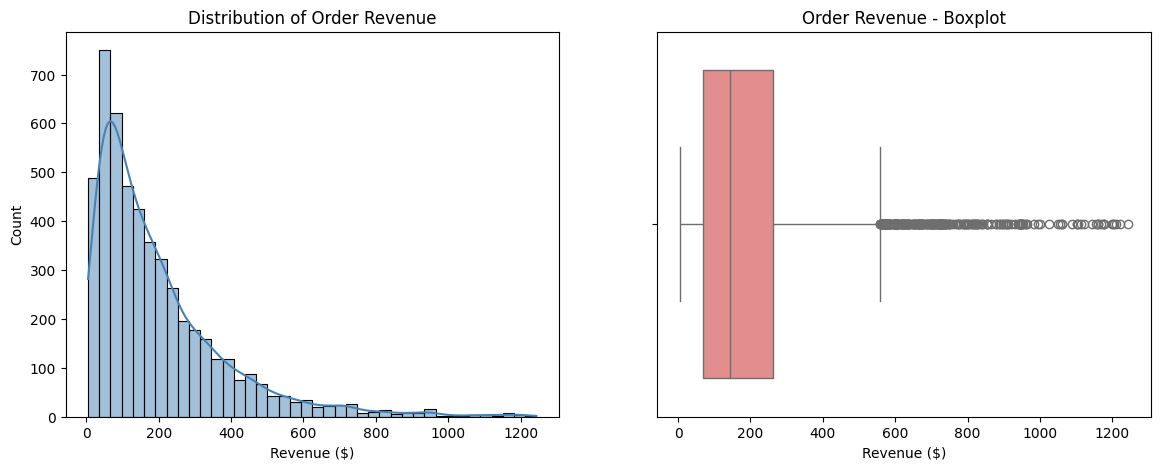

In [18]:
# Revenue Distribution

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

sns.histplot(df['Revenue'], bins = 40, kde = True, ax = axes[0], color = 'steelblue')
axes[0].set_title('Distribution of Order Revenue')
axes[0].set_xlabel('Revenue ($)')

sns.boxplot(x = df['Revenue'], ax = axes[1], color = 'lightcoral')
axes[1].set_title('Order Revenue - Boxplot')
axes[1].set_xlabel('Revenue ($)')




/tmp/ipykernel_11609/913857831.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = revenue_by_category.values, y = revenue_by_category.index, palette = 'viridis')


,Revenue
Category,
Electronics,321957.73
Sports,191778.22
Apparel,166219.70
Home & Kitchen,121613.29
Toys,108485.57
Beauty,82024.83


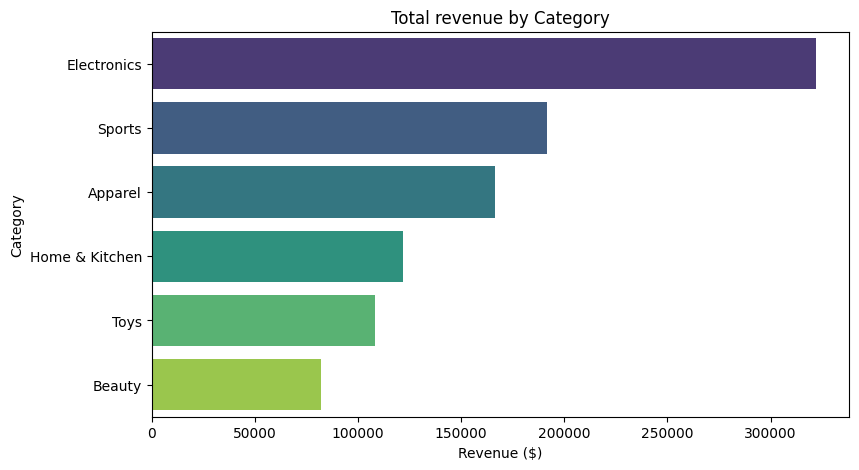

In [19]:
# Revenue by category
revenue_by_category = (
    df.groupby('Category')['Revenue'].sum().sort_values(ascending = False)
)

plt.figure(figsize = (9, 5))
sns.barplot(x = revenue_by_category.values, y = revenue_by_category.index, palette = 'viridis')
plt.title('Total revenue by Category')
plt.xlabel('Revenue ($)')
plt.ylabel('Category')
revenue_by_category


/tmp/ipykernel_11609/1190917175.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = revenue_by_region.index, y = revenue_by_region.values, palette = 'magma')


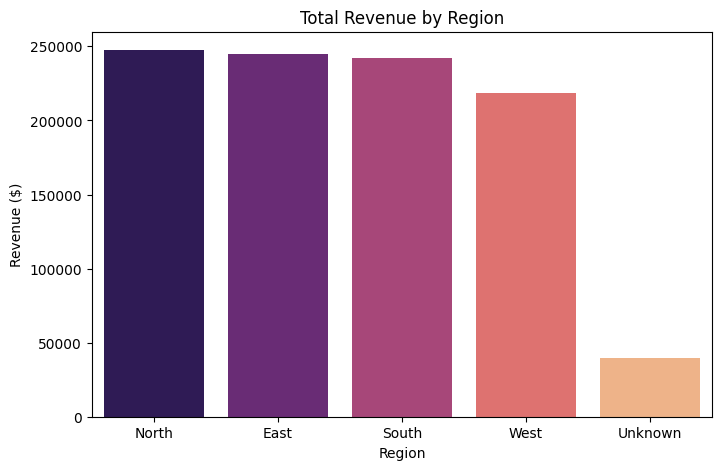

,Revenue
Region,
North,247508.46
East,244827.86
South,241992.08
West,218418.73
Unknown,39332.21


In [20]:
# Revenue by region
revenue_by_region = (
    df.groupby('Region')['Revenue']
    .sum()
    .sort_values(ascending = False)
)

plt.figure(figsize = (8, 5))
sns.barplot(x = revenue_by_region.index, y = revenue_by_region.values, palette = 'magma')

plt.title('Total Revenue by Region')
plt.ylabel('Revenue ($)')
plt.show()

revenue_by_region

# 5. Time-Based Trend Analysis

,Revenue
Month,
2025-01,51549.07
2025-02,50823.81
2025-03,64807.47
2025-04,69565.98
2025-05,83077.12
2025-06,70191.64
2025-07,78636.85
2025-08,91096.60
2025-09,92458.13


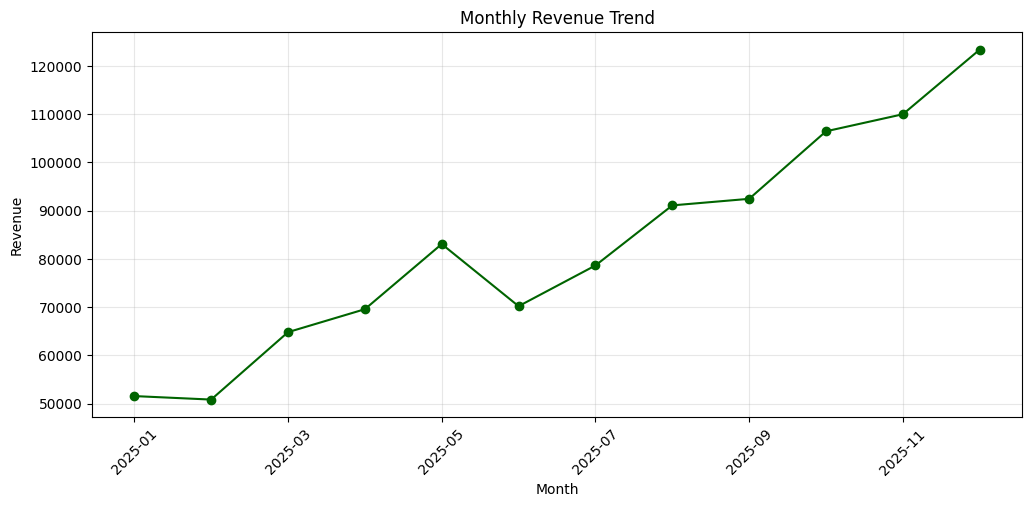

In [21]:
# Monthly revenue trend
# This is the single most common chart a business stakeholder asks for:
# "is revenue going up or down?"

monthly_revenue = df.groupby('Month')['Revenue'].sum().sort_index()

plt.figure(figsize = (12, 5))
monthly_revenue.plot(kind = 'line', marker = 'o', color = 'darkgreen')

plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.xticks(rotation = 45)
plt.grid(True, alpha = 0.3)

monthly_revenue

/tmp/ipykernel_11609/191720380.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = revenue_by_day.index, y = revenue_by_day.values, palette = 'coolwarm')


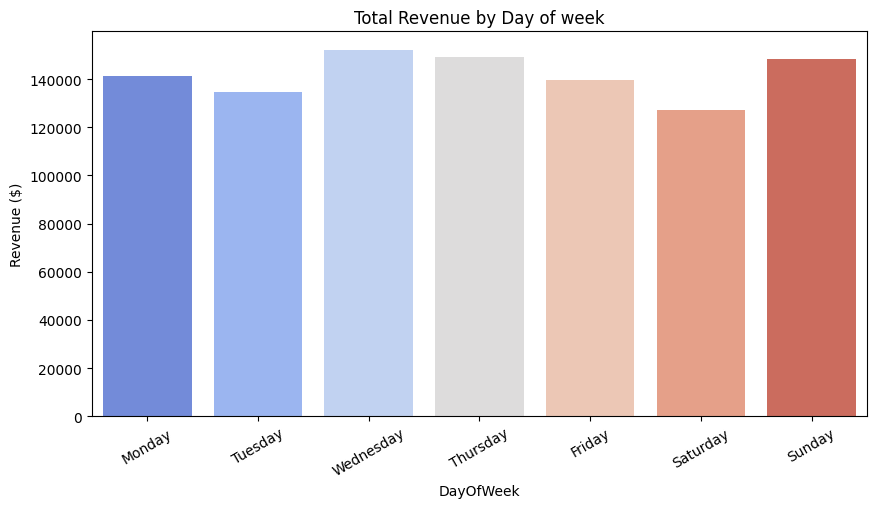

In [22]:
# Weekday vs weekend pattern
# Ordered explicitly (Mon -> Sun) so the chart reads naturally instead of
# alphabetically, which is the default pandas would show

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
revenue_by_day = df.groupby('DayOfWeek')['Revenue'].sum().reindex(day_order)

plt.figure(figsize = (10, 5))

sns.barplot(x = revenue_by_day.index, y = revenue_by_day.values, palette = 'coolwarm')

plt.title('Total Revenue by Day of week')
plt.ylabel('Revenue ($)')
plt.xticks(rotation = 30)
plt.show()

# 6 Customer Segmentation (RFM Analysis)
RFM Scores each customer on three dimensions
- Recency - days since their last order (lower = more recently active)
- Frequency - number of distinct orders placed
- Monetary - total revenue contributed

We score each dimension 1-4 using quartiles, combine into a single RFM segment label and use that to identify our most valuable customers vs those at risk of churning

In [23]:
# Reference data = one day after the last order in the dataset, so 'days since last order' is
# always a positive number, even for someone who ordered on the last day

snapshot_date = df['OrderDate'].max() + pd.Timedelta(days = 1)

rfm = df.groupby('CustomerID').agg(
    Recency = ('OrderDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('OrderDate', 'count'),
    Monetary = ('Revenue', 'sum')
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,CUST0001,22,5,1294.77
1,CUST0002,16,7,1050.29
2,CUST0003,91,7,929.88
3,CUST0004,55,7,781.21
4,CUST0005,6,5,970.21


In [24]:
# Score each metric 1-4 using quartiles (4 = best)
# Recency is reversed (qcut labels 4, 3, 2, 1) because a SMALL recency (recent order is GOOD)
# the opposite direction for Frequency/Monetary where bigger is better

rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels = [4, 3, 2, 1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method = 'first'), 4, labels = [1, 2, 3 , 4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels = [1, 2, 3, 4]).astype(int)


rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

In [25]:
rfm

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,CUST0001,22,5,1294.77,3,2,3,8
1,CUST0002,16,7,1050.29,3,3,2,8
2,CUST0003,91,7,929.88,1,3,2,6
3,CUST0004,55,7,781.21,2,3,2,7
4,CUST0005,6,5,970.21,4,2,2,8
...,...,...,...,...,...,...,...,...
792,CUST0796,12,6,1044.42,4,3,2,9
793,CUST0797,38,7,1228.29,2,3,3,8
794,CUST0798,12,15,2986.87,4,4,4,12
795,CUST0799,86,3,830.14,1,1,2,4


In [26]:
# Translate the numeric score into a plain-language segement label -
# this is the part a non-technical person actually wants to see

def label_segment(score):
  if score >= 10:
    return 'Champions'
  elif score >=8:
    return 'Loyal Customers'
  elif score >= 6:
    return 'Potential Loyalists'
  elif score >=4:
    return 'At risk'
  else:
    return 'Lost/Inactive'


rfm['Segment'] = rfm['RFM_score'].apply(label_segment)

In [27]:
rfm

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
0,CUST0001,22,5,1294.77,3,2,3,8,Loyal Customers
1,CUST0002,16,7,1050.29,3,3,2,8,Loyal Customers
2,CUST0003,91,7,929.88,1,3,2,6,Potential Loyalists
3,CUST0004,55,7,781.21,2,3,2,7,Potential Loyalists
4,CUST0005,6,5,970.21,4,2,2,8,Loyal Customers
...,...,...,...,...,...,...,...,...,...
792,CUST0796,12,6,1044.42,4,3,2,9,Loyal Customers
793,CUST0797,38,7,1228.29,2,3,3,8,Loyal Customers
794,CUST0798,12,15,2986.87,4,4,4,12,Champions
795,CUST0799,86,3,830.14,1,1,2,4,At risk


In [29]:
# Visualize how many customers - and how much revenue - fall into each segment

segment_summary = rfm.groupby('Segment').agg(
    Customers = ('CustomerID', 'count'),
    TotalRevenue = ('Monetary', 'sum')
).sort_values('TotalRevenue', ascending = False)

segment_summary

,Customers,TotalRevenue
Segment,,
Champions,218,416469.45
Loyal Customers,192,280274.45
Potential Loyalists,183,173383.09
At risk,136,94215.93
Lost/Inactive,68,27736.42


/tmp/ipykernel_11609/3007856313.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = segment_summary.index, y = segment_summary['Customers'], ax = axes[0], palette = 'Set2')
/tmp/ipykernel_11609/3007856313.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = segment_summary.index , y = segment_summary['TotalRevenue'], ax = axes[1], palette = 'Set2')


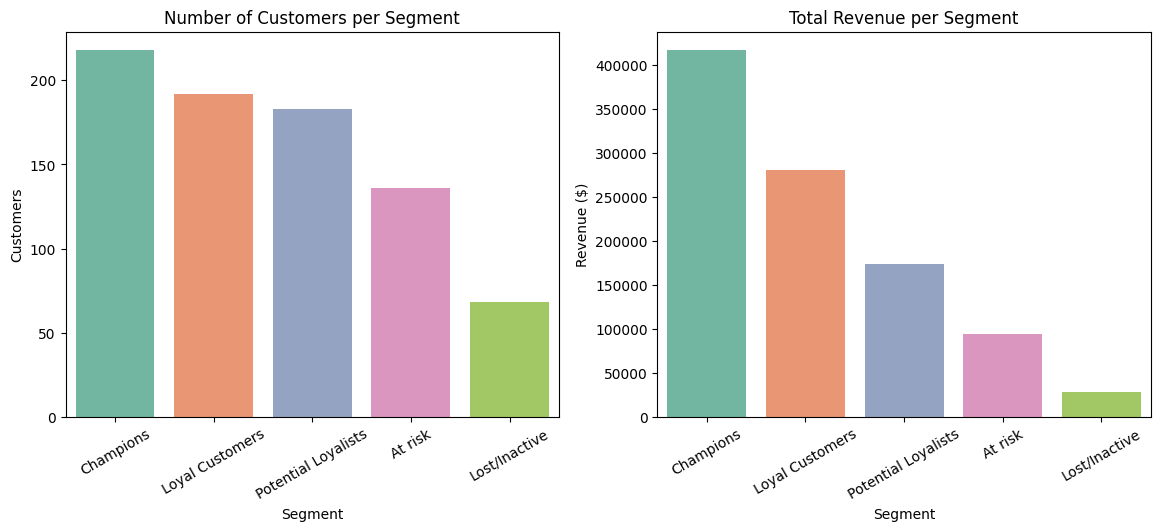

In [30]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
sns.barplot(x = segment_summary.index, y = segment_summary['Customers'], ax = axes[0], palette = 'Set2')
axes[0].set_title('Number of Customers per Segment')
axes[0].tick_params(axis = 'x', rotation = 30)

sns.barplot(x = segment_summary.index , y = segment_summary['TotalRevenue'], ax = axes[1], palette = 'Set2')
axes[1].set_title('Total Revenue per Segment')
axes[1].set_ylabel('Revenue ($)')
axes[1].tick_params(axis = 'x', rotation = 30)

# 7 Product Performance

In [31]:
# Top 10 Products by revenue - useful for inventory/marketing priortization
top_products = (
    df.groupby('Product')['Revenue']
    .sum()
    .sort_values(ascending = False)
    .head(10)
)
top_products

,Revenue
Product,
Smartwatch,88080.29
Wireless Earbuds,80875.38
Bluetooth Speaker,77078.46
Laptop Stand,75923.60
Yoga Mat,50164.36
Resistance Bands,48528.87
Dumbbell Set,47683.83
Water Bottle,45401.16
Winter Jacket,44264.71


/tmp/ipykernel_11609/3567453910.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_products.values, y = top_products.index, palette = 'crest')


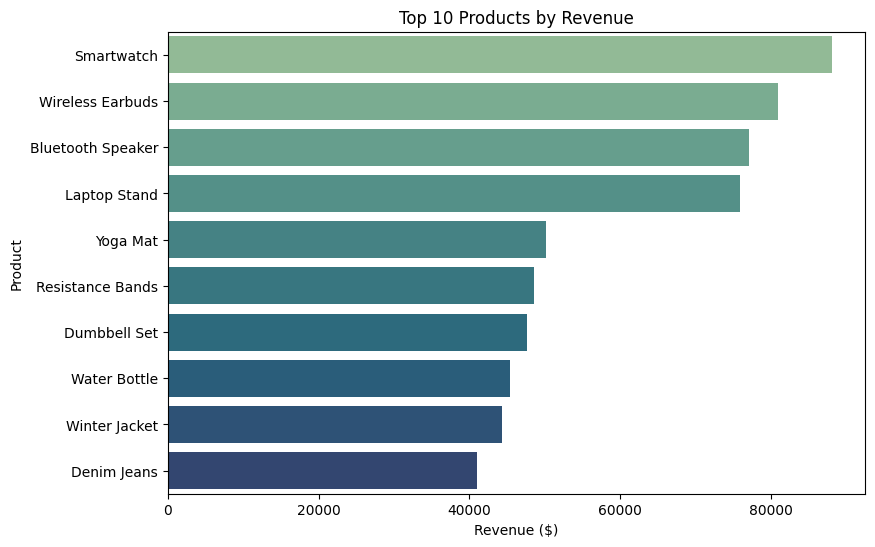

In [32]:
plt.figure(figsize = (9, 6))
sns.barplot(x = top_products.values, y = top_products.index, palette = 'crest')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue ($)')
plt.show()

# 8. Correlation & Hypothesis Testing

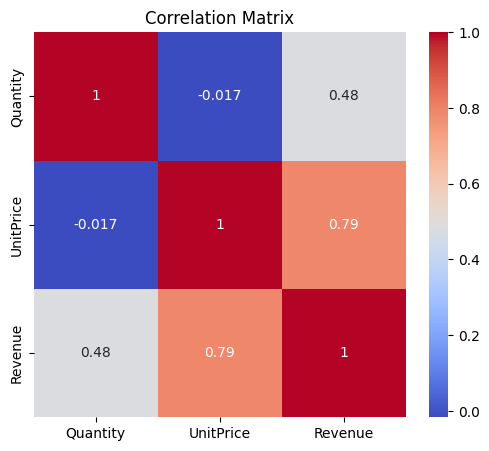

In [33]:
# Correlation heatmap

numeric_cols = ['Quantity', 'UnitPrice', 'Revenue']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize = (6, 5))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm')

plt.title('Correlation Matrix')
plt.show()

# 9 Business Insights & Recommendations

In [34]:
# Pulling together key numbers computed above into one readable summary block
# In a real job, this is the paragraph that goes into the email to your manager.

top_category = revenue_by_category.idxmax()
top_region = revenue_by_region.idxmax()
best_month = monthly_revenue.idxmax()

champions_count = (rfm['Segment'] == 'Champions').sum()
champions_revenue_share = rfm.loc[rfm['Segment'] == 'Champions', 'Monetary'].sum() / rfm['Monetary']


print('KEY INSIGHTS')
print('=' * 50)

print(f'1. {top_category} is the top-performing category by revenue')
print(f'2. The {top_region} region generates the most revenue')
print(f'3. {best_month} was the strongest month - consistent with holiday-season lift')

print(f'4. {champions_count} customers (Champions segment) drive' f'{champions_revenue_share} of total revenue')


KEY INSIGHTS
1. Electronics is the top-performing category by revenue
2. The North region generates the most revenue
3. 2025-12 was the strongest month - consistent with holiday-season lift
4. 218 customers (Champions segment) drive0      321.655159
1      396.528054
2      447.874403
3      533.108191
4      429.257017
          ...    
792    398.756678
793    339.064431
794    139.433404
795    501.685800
796    803.545216
Name: Monetary, Length: 797, dtype: float64 of total revenue
